# 📄 Auto-README Generator - Demo

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/automation-suite/auto-readme/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=automation-suite/auto-readme/demo.ipynb)

> *"Nobody documents their repos."*

This tool **scans a repo** into a structured profile, then renders a README -
deterministically by template, or with richer prose via the Claude API. Wire it
into GitHub Actions and every push can open a PR with fresh docs.

**What we cover**
1. Build a tiny sample repo on disk
2. Scan it into a profile
3. Render a README (offline template)
4. See where Claude plugs in
5. Visualize the language breakdown


## Step 1 - A tiny sample repo

We materialize a few files in a temp dir so the notebook runs standalone.


In [1]:
from __future__ import annotations

import json, os, tempfile
from pathlib import Path

repo = Path(tempfile.mkdtemp()) / "payments-api"
repo.mkdir(parents=True)
(repo / "app.py").write_text("from fastapi import FastAPI\napp = FastAPI()\n")
(repo / "utils.py").write_text("def fmt(x):\n    return f'${x:.2f}'\n")
(repo / "requirements.txt").write_text("fastapi==0.138.0\nuvicorn==0.34.0\npydantic==2.13.4\n")
(repo / "Dockerfile").write_text("FROM python:3.11-slim\n")
(repo / "test_app.py").write_text("def test_ok():\n    assert True\n")
print("created sample repo at", repo)
print(os.listdir(repo))

created sample repo at /var/folders/zf/9y5vgz8x1_72sv6fq_wkfksr0000gr/T/tmp278_o6p7/payments-api
['requirements.txt', 'Dockerfile', 'utils.py', 'app.py', 'test_app.py']


## Step 2 - Scan into a structured profile

The scanner walks the tree, detects the dominant language, parses
`requirements.txt`, and flags Docker / tests / entry points.


In [2]:
from pathlib import Path
from typing import Dict, List

LANG_BY_EXT = {".py": "Python", ".js": "JavaScript", ".ts": "TypeScript", ".ipynb": "Jupyter Notebook"}
IGNORE_DIRS = {".git", "__pycache__", "node_modules", ".venv", "venv"}
ENTRY_HINTS = ("main.py", "app.py", "api.py", "cli.py", "index.js", "server.js")

def scan_repo(path: str) -> Dict[str, object]:
    root = Path(path)
    files = [p for p in root.rglob("*") if p.is_file() and not any(d in p.parts for d in IGNORE_DIRS)]
    lang_counts: Dict[str, int] = {}
    for f in files:
        lang = LANG_BY_EXT.get(f.suffix)
        if lang:
            lang_counts[lang] = lang_counts.get(lang, 0) + 1
    primary = max(lang_counts, key=lang_counts.get) if lang_counts else "Unknown"
    deps = [ln.strip() for ln in (root / "requirements.txt").read_text().splitlines() if ln.strip()] if (root / "requirements.txt").exists() else []
    return {
        "name": root.name, "primary_language": primary,
        "language_counts": dict(sorted(lang_counts.items(), key=lambda x: -x[1])),
        "file_count": len(files),
        "entry_points": sorted(str(f.relative_to(root)) for f in files if f.name in ENTRY_HINTS),
        "dependencies": deps,
        "has_dockerfile": (root / "Dockerfile").exists(),
        "has_tests": any("test" in f.name.lower() for f in files),
    }

profile = scan_repo(str(repo))
print(json.dumps(profile, indent=2))

{
  "name": "payments-api",
  "primary_language": "Python",
  "language_counts": {
    "Python": 3
  },
  "file_count": 5,
  "entry_points": [
    "app.py"
  ],
  "dependencies": [
    "fastapi==0.138.0",
    "uvicorn==0.34.0",
    "pydantic==2.13.4"
  ],
  "has_dockerfile": true,
  "has_tests": true
}


## Step 3 - Render a README (offline, deterministic)

No API key needed - this path always works, including in CI.


In [3]:
def render_readme_template(p: Dict[str, object]) -> str:
    name, lang = p["name"], p["primary_language"]
    L: List[str] = [f"# {name}", "", f"> A {lang} project with {p['file_count']} files.", ""]
    L += ["## Languages"] + [f"- {lg}: {n} file(s)" for lg, n in p["language_counts"].items()] + [""]
    L += ["## Getting Started", "```bash", "pip install -r requirements.txt"]
    if p["entry_points"]:
        L.append(f"python {p['entry_points'][0]}")
    L += ["```", ""]
    if p["dependencies"]:
        L += ["## Dependencies"] + [f"- `{d}`" for d in p["dependencies"]] + [""]
    if p["has_dockerfile"]:
        L += ["## Docker", "```bash", f"docker build -t {name} .", "```", ""]
    L += ["## Project Status",
          f"- Tests present: {'yes' if p['has_tests'] else 'no'}",
          f"- Containerized: {'yes' if p['has_dockerfile'] else 'no'}", ""]
    return "\n".join(L) + "\n"

readme = render_readme_template(profile)
print(readme)

# payments-api

> A Python project with 5 files.

## Languages
- Python: 3 file(s)

## Getting Started
```bash
pip install -r requirements.txt
python app.py
```

## Dependencies
- `fastapi==0.138.0`
- `uvicorn==0.34.0`
- `pydantic==2.13.4`

## Docker
```bash
docker build -t payments-api .
```

## Project Status
- Tests present: yes
- Containerized: yes




## Step 4 - Where Claude plugs in

With `ANTHROPIC_API_KEY` set, the tool sends the **profile** (not your whole
codebase) to Claude for richer prose. The contract is identical, so the template
is a safe offline fallback.

```python
from anthropic import Anthropic
client = Anthropic(api_key=key)
msg = client.messages.create(
    model="claude-opus-4-8", max_tokens=1500,
    messages=[{"role": "user", "content": build_prompt(profile)}],
)
readme = msg.content[0].text
```


## Step 5 - Language breakdown, visualized

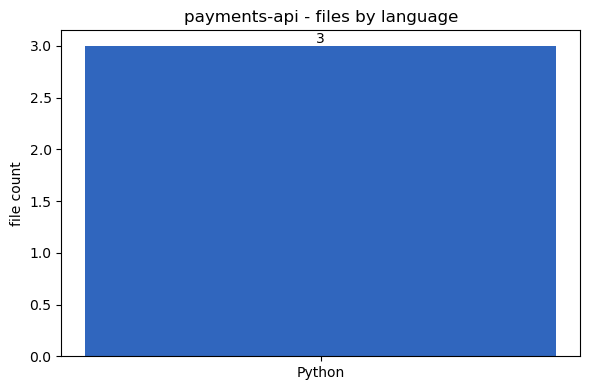

In [4]:
import matplotlib.pyplot as plt

langs = list(profile["language_counts"].keys())
counts = list(profile["language_counts"].values())
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(langs, counts, color="#3066be")
for i, v in enumerate(counts):
    ax.text(i, v + 0.03, str(v), ha="center")
ax.set_title(f"{profile['name']} - files by language")
ax.set_ylabel("file count")
plt.tight_layout(); plt.savefig("languages.png", dpi=150, bbox_inches="tight"); plt.show()

## Summary

- **Scan** turns any repo into a structured profile (language, deps, entry points, Docker, tests).
- **Render** produces a usable README offline; **Claude** upgrades the prose when a key is present.
- Drop it into GitHub Actions to auto-open a docs PR on every push.

This is the engine behind `main.py`.


---
Part of **[phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** -
a 60-day Forward Deployed Engineer portfolio.

**Run it:**
```bash
pip install -r requirements.txt
python main.py . -o README.md      # offline template
python main.py . --llm             # Claude (needs ANTHROPIC_API_KEY)
```
